In [1]:
from pathlib import Path

from ipywidgets import Dropdown, interactive
from visualization import (
    show_bgr_image,
)

import draftslice.core.io as io

DATASET_FOLDER = Path("../data")

In [2]:
source_files: list[Path] = sorted(DATASET_FOLDER.glob("*.jpg"))
print(f"файлов в датасете: {len(source_files)}")


def run_source(file_index: int) -> Path:
    """Выбор файла из датасета."""
    source_path = source_files[file_index]
    image = io.load_image(str(source_path))

    show_bgr_image(image, f"[{file_index}] {source_path.stem} | {image.shape[0]}x{image.shape[1]}")
    return source_path


ui_source = interactive(
    run_source,
    file_index=Dropdown(
        options=[(f"[{index}] {path.stem}", index) for index, path in enumerate(source_files)],
        value=0,
        description="файл",
    ),
)
ui_source

файлов в датасете: 21


interactive(children=(Dropdown(description='файл', options=(('[0] 01', 0), ('[1] 02', 1), ('[2] 03', 2), ('[3]…

In [3]:
from draftslice.core.common.types import Mat
from draftslice.core.extractors.text.detector import TextProbabilityDetector

img: Mat = io.load_image(ui_source.result)

MODEL_PATH = Path("../models/PP-OCRv5_server_det_infer.onnx")
DETECTOR_SCALES: tuple[int, ...] = (320, 640, 980)
detector = TextProbabilityDetector(MODEL_PATH)

In [4]:
predicts = detector.detect_multiscale(img, DETECTOR_SCALES)

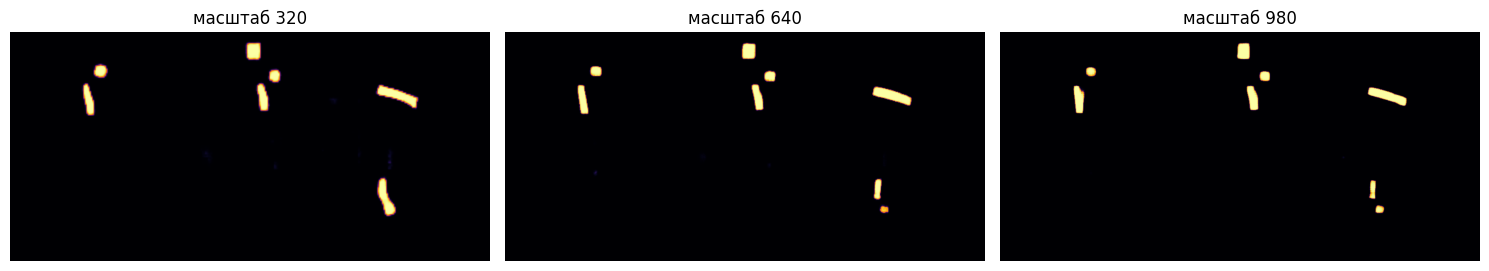

In [5]:
from visualization import show_probs

show_probs(predicts, DETECTOR_SCALES)

In [6]:
predicts.shape

(3, 518, 1085)

TypeError: Invalid shape () for image data

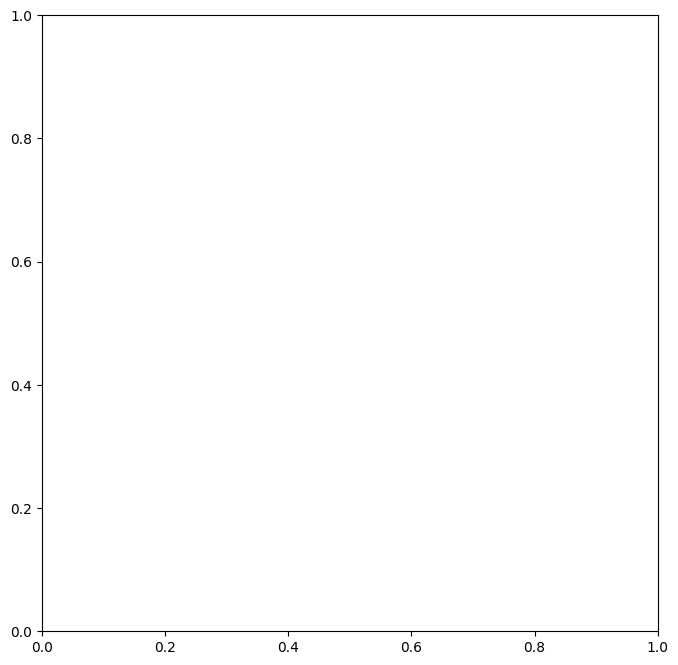

In [8]:
import numpy as np
from visualization import show_prob_map

results = np.mean(predicts)
show_prob_map(results)